In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

%run 0A.data_check_n_clean.ipynb

safely removed countries w.o fao/sif/mask data: True 



In [2]:
combined= pd.DataFrame()
failed_countries = []

for i in allcountries:
    try:
        print(i)
        ugh = {}
        %run 0B.csif_proxy_fxs_update.ipynb
        combined = combined.append(ugh)
    except Exception as e:
        print(f"Error processing {i}: {e}")
        failed_countries.append(i)
    print("\n")

/Users/caropark/Dropbox (Harvard University)/DataByCountry/Dominican Republic
CPU times: user 301 ms, sys: 64.1 ms, total: 365 ms
Wall time: 386 ms


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Djibouti
CPU times: user 79.9 ms, sys: 8.11 ms, total: 88 ms
Wall time: 92.9 ms


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Morocco
CPU times: user 1.43 s, sys: 535 ms, total: 1.97 s
Wall time: 1.98 s


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Zambia
CPU times: user 3.73 s, sys: 1.38 s, total: 5.11 s
Wall time: 5.18 s


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Equatorial Guinea
CPU times: user 91.4 ms, sys: 18.9 ms, total: 110 ms
Wall time: 116 ms


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Brunei Darussalam
CPU times: user 90.9 ms, sys: 8.32 ms, total: 99.2 ms
Wall time: 104 ms


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Burkina Faso
CPU times: user 1.54 s, sys: 473 ms, total: 2.01 s
Wall time:

ValueError: cannot insert yield, already exists

Error processing /Users/caropark/Dropbox (Harvard University)/DataByCountry/Faroe Islands: Can only append a dict if ignore_index=True


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Congo
CPU times: user 604 ms, sys: 141 ms, total: 745 ms
Wall time: 754 ms


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Ireland
CPU times: user 363 ms, sys: 81.1 ms, total: 444 ms
Wall time: 452 ms


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Mongolia
CPU times: user 5.76 s, sys: 1.78 s, total: 7.54 s
Wall time: 7.58 s


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Ethiopia
CPU times: user 4.84 s, sys: 1.4 s, total: 6.25 s
Wall time: 6.26 s


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Mauritania
CPU times: user 1.08 s, sys: 300 ms, total: 1.38 s
Wall time: 1.39 s


/Users/caropark/Dropbox (Harvard University)/DataByCountry/Yemen
CPU times: user 406 ms, sys: 94.3 ms, total: 500 ms
Wall time: 510 ms


/Users/caropark/Dropbox (Harvard 

In [3]:
failed_countries

['/Users/caropark/Dropbox (Harvard University)/DataByCountry/Faroe Islands']

In [4]:
combined = combined.reset_index(drop=True)
combined['yield_og'] = combined['yield']
combined.loc[combined.whichlag == "yield_lead", 'yield'] = combined["yield_lead"]
combined.loc[combined.whichlag == "yield_lag", 'yield'] = combined["yield_lag"]
isos = pd.read_csv("./data/country_key.csv")[["country", "iso_a3"]]
combined = combined.merge(isos, how="left", on="country")
combined.to_pickle("./data/combined_update.pkl")  

import feather
path = './data/combined_update.feather'
feather.write_dataframe(combined, path)

### check USA

/var/folders/k4/2gcvspsj7d7c9hbxlvzv_zrh0000gn/T/ipykernel_1603/1620031695.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ugh['yield'] = ugh.reindex(cols, axis=1).to_numpy()[np.arange(len(ugh)), idx]


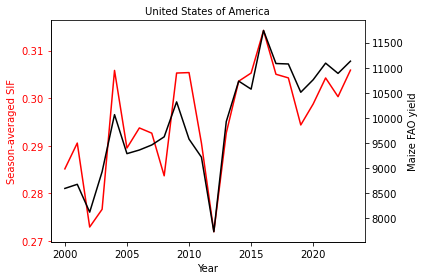

In [5]:
plotme(combined[combined['country']=="United States of America"], "Maize")

/var/folders/k4/2gcvspsj7d7c9hbxlvzv_zrh0000gn/T/ipykernel_1603/942901996.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ugh['yield'] = ugh.reindex(cols, axis=1).to_numpy()[np.arange(len(ugh)), idx]


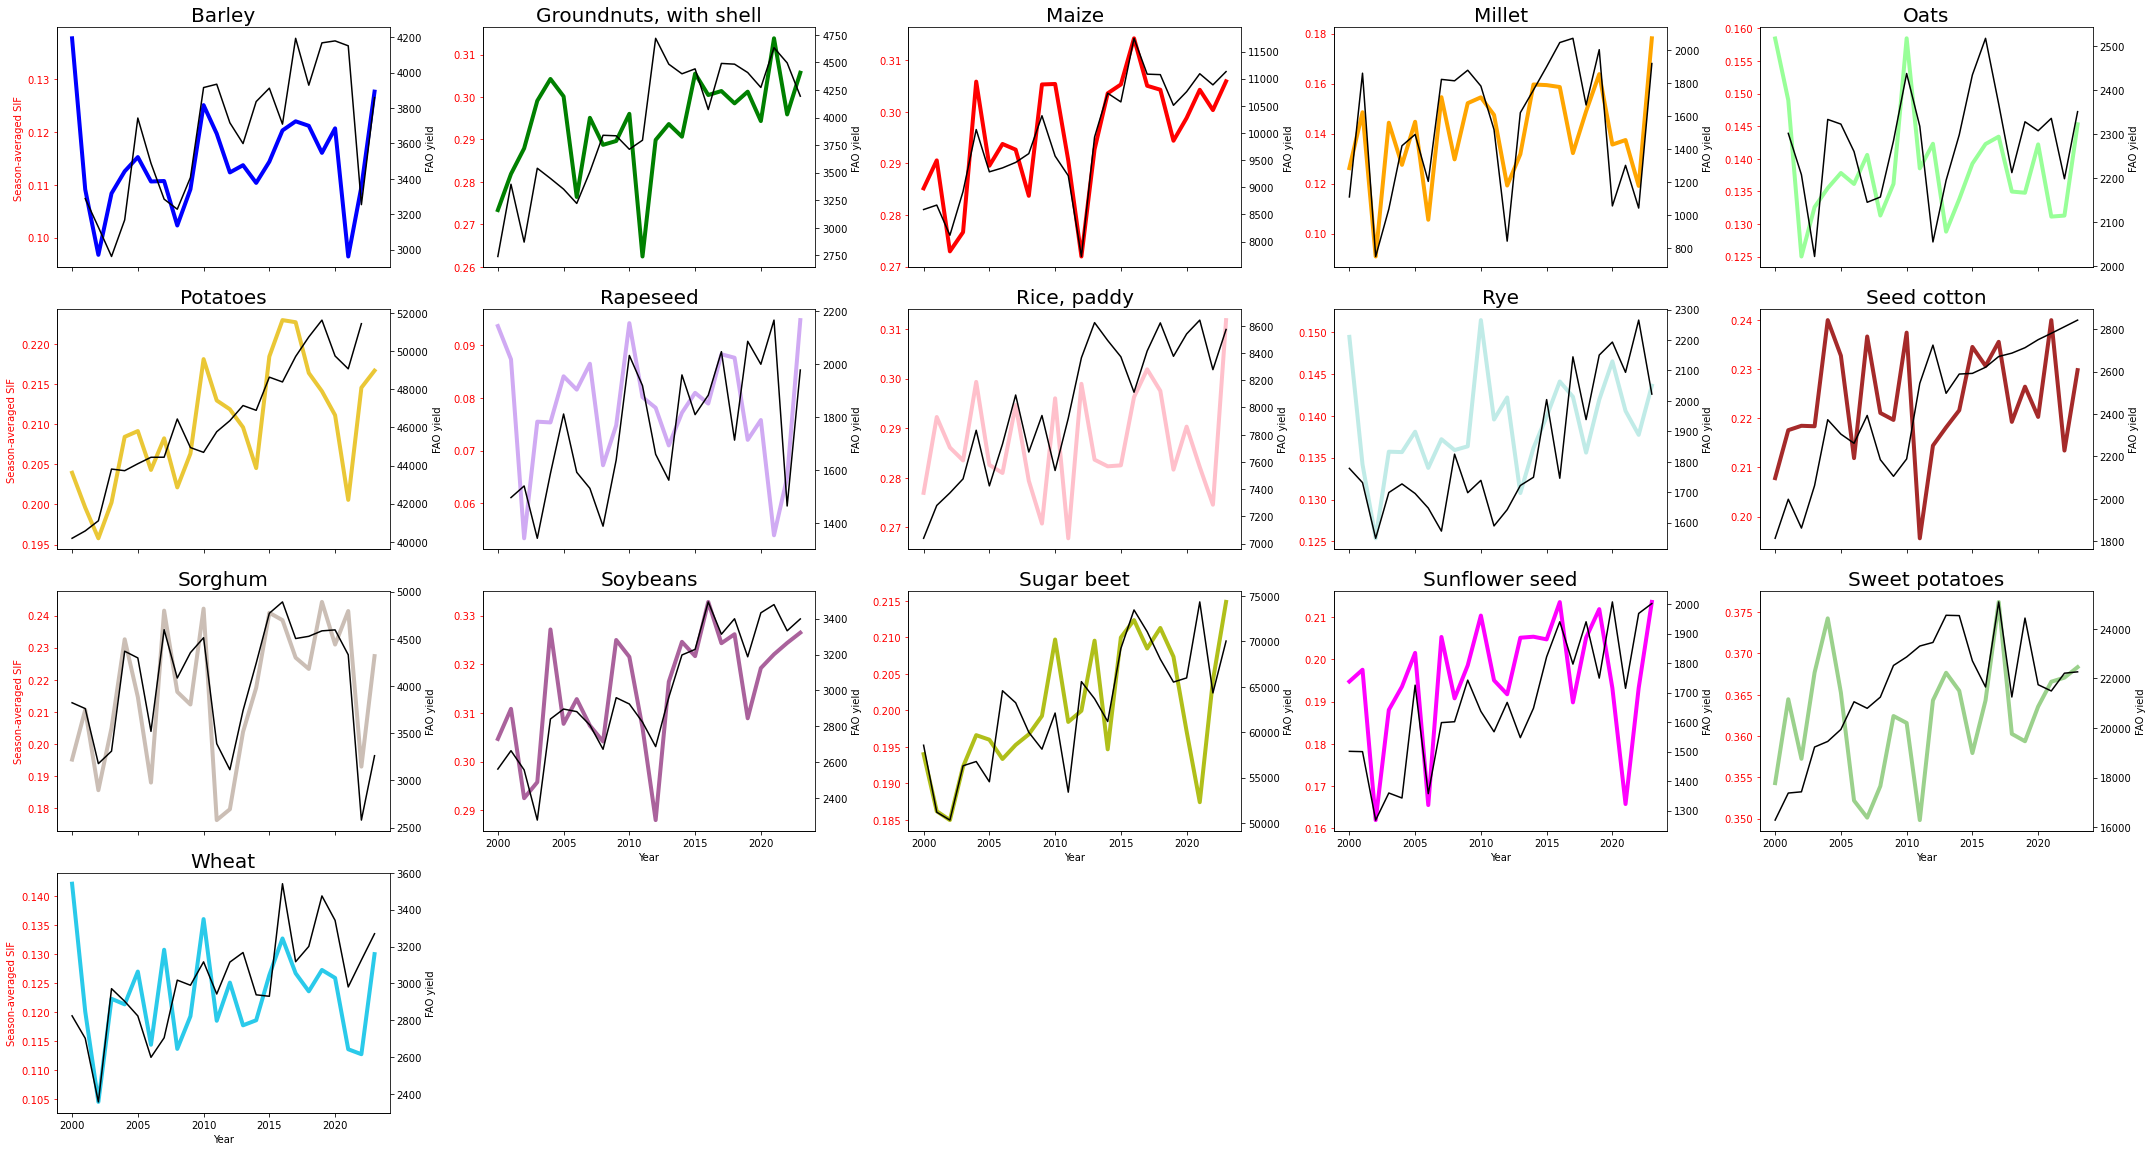

In [6]:
plotme_facet(combined[combined['country']=="United States of America"])

In [7]:
os.system('say "hell yeah"')

0